###$ ANALYSIS NOTEBOOK

In [153]:
%run common_setup.ipynb

In [154]:
class WorksPairPlotter(SetUp):

    def __init__(self):
        super().__init__()
        return
    
    def extract_work_data(self):
        self.data = self.db.sql("SELECT * FROM project.work_summary").df()
        print(self.data.head())
        return
    
    def plot_pairplot(self):
        # self.data = self.data.sort_values('percent_rank_total_endogenous')
        cols = ['cited_by_count', 'cited_by_count_endogenous', 'references_per_page',
                'fwci', 'fwci_endogenous', 'copied_percent',  'disruption_index', 'citer_topics_count', 'pagerank_source' ]
        data1 = self.data.loc[self.data.isHighlyCited == True, cols].copy()
        data1['status'] = 'HCA'
        data2 = self.data.loc[self.data.isHighlyCited != True, cols].copy()
        data2['status'] = 'notHCA'
        print(f'{data1.shape = } {data2.shape = }')
        data = pd.concat([data1, data2], axis=0)
        print(f'{data.shape = }\n{data.head()}')
        sns.pairplot(data, hue='status')
        plt.show()
        

In [155]:
class WorksHistoPlotter(SetUp):

    def __init__(self):
        super().__init__()
        return
    
    def extract_work_data(self):
        self.data = self.db.sql("SELECT * FROM project.work_summary").df()
        print(self.data.head())
        return
    
    def describe_data(self):
        col_list = [f"{c}" for c in self.data.columns]
        print(col_list)
        columns = ['cited_by_count', 'cited_by_count_endogenous', 'referenced_works_count', 'references_per_page', 
                   'fwci', 'fwci_endogenous', 
                   'copied_percent', 'disruption_index', 
                   'cited_topics_count', 'citer_topics_count', 
                   'pagerank_source', 'influence_source', 'pagerank_institution', 'influence_institution']

        self.data['hue'] =['HC' if x else 'notHC' for x in self.data.isHighlyCited] 
        for kount, indicator in enumerate(columns):
            self.data[indicator] = self.data[indicator].replace([np.inf, -np.inf], np.nan)
            # if kount != 7 and kount != 6:
            #     continue
            self.data[indicator] = pd.to_numeric(self.data[indicator], errors='coerce').dropna()
            text = self.data[indicator].describe(percentiles=[0.01, 0.5, 0.99]).to_frame()
            top = self.data.sort_values(indicator, ascending=False).head(1)
            print(top)
            top_work = top.iloc[0,0]
            print(top_work)
            top_value = self.data[indicator].quantile(0.99)
            max_value = self.data[indicator].quantile(1.0)
            if max_value < 10.0:
                self.data[indicator] = 100*self.data[indicator]
                top_value *= 100
            top_value = int(top_value)
            bin_count = top_value
            if bin_count < 10:
                bin_count *= 10
            bin_count = 100 
            fig, ax = plt.subplots()
            p = sns.histplot(data=self.data, x=indicator, bins=bin_count, binrange=(0.0, top_value), hue='hue')
            ax.text(x=0.7, y=0.9, s=text, horizontalalignment='center', verticalalignment='top', transform=ax.transAxes)
            ax.text(x=0.7, y=0.45, s=f'OA work at max {top_work}', horizontalalignment='center', verticalalignment='top', transform=ax.transAxes, size=8)
            # ax.set_xscale('log')
            plt.show()
        return



In [156]:
class TimeSeries(SetUp):

    def __init__(self):
        super().__init__()
        return
    
    def basic_time_series(self):
        print('basic time series')
        sql = """
            SELECT publication_year AS 'publication_year', 
                    count(work_id) AS 'works_count',
                    sum(cited_by_count)/count(work_id) AS 'mean_cites',
                    sum(referenced_works_count)/count(work_id) AS 'mean_references'
                FROM workssudo apt-get install libcairo2-dev
                GROUP BY publication_year
                ORDER BY publication_year
            """
        df = self.db.sql(sql).df()
        print(f'{df.shape = }\n{df.head()}')
        self.plot_basic_time_series(df=df)
        return
    
    def plot_basic_time_series(self, df=None):
        fig, ax = plt.subplots(1, 1)
        sns.lineplot(df, x='publication_year', y='mean_references', ax=ax)
        ax.set_ylim((0, 50))
        ax.set_xlim((2010, 2025))
        plt.show()

        fig, ax = plt.subplots(1, 1)
        sns.lineplot(df, x='publication_year', y='works_count', ax=ax)
        ax.set_ylim((0, 50000))
        ax.set_xlim((2010, 2025))
        plt.show()
        return

    def authorship_time_series(self):
        sql = """
                SELECT DISTINCT author_id, 
                                author_name AS 'author name',
                                works_count,
                                cites_count,
                                cites_count//works_count AS cites_per_work,
                                start_year,
                                end_year,
                                -- publication_years,
                                works_count//(1+end_year-start_year) AS 'pub_rate_per_year'
                    FROM
                        (SELECT author_id,
                                author_name,
                                count(DISTINCT work_id) AS works_count,
                                sum(cited_by_count) AS cites_count,
                                min(publication_year) AS start_year,
                                max(publication_year) AS end_year,
                                -- list(publication_year) AS publication_years
                            FROM authorships a
                                LEFT JOIN works w
                                USING (work_id)
                                WHERE contains('article review preprint letter', w.type) = true 
                                    -- AND w.title != 'Frontmatter'
                                GROUP BY author_id, author_name
                        )
                    ORDER BY works_count DESC --cites_per_work DESC -- pub_rate_per_year DESC --works_count DESC
            """
        df = self.db.sql(sql).df()
        df.to_csv('../DATA/authorship_time_series.csv')
        return
    
    def journal_edge_list(self):
        # SQL code to assemble the source-source edge list with the count of work-work citations as weights
        sql = """
        CREATE OR REPLACE TABLE econ.source_citations AS
        SELECT --sub.work_id,
                --sub.cited_id,
                sub.source_id AS citer_id,
                ww.source_id AS cited_id,
                count(ww.work_id) AS weights,
        FROM
            (SELECT w.work_id,
                    w.source_id,
                    w.cited_by_count,
                    unnest(c.referenced_works) AS cited_id
            FROM works w
            LEFT JOIN cited c
            USING (work_id)
            WHERE w.source_id NOT NULL) sub 
            
        LEFT JOIN works ww
            ON ww.work_id = sub.cited_id
            WHERE ww.source_id NOT NULL
        GROUP BY sub.source_id, ww.source_id
        ORDER BY weights DESC
        """
        self.db.sql(sql)
        return

    def journal_citations(self):
        df = self.db.sql("SELECT * FROM econ.source_citations").df()
        df = df[df.citer_id != df.cited_id]
        df = df[df.weights > 1000]
        print(f'{df.shape = }\n{df.head()}')
        g = ig.Graph.DataFrame(df, directed=True, use_vids=False)
        layout = g.layout(layout="circle")
        fig, ax = plt.subplots()
        ig.plot(g, bbox=(0, 0, 100, 100), target=ax, layout=layout, vertex_size=2, edge_width=1, edge_arrow_width=1)
        plt.show()
        return

In [157]:
class Distributions(SetUp):

    def __init__(self):
        super().__init__()
        return
    
    def source_works(self):
        df = self.db.sql("SELECT * FROM works").df()[['work_id', 'source_id']]
        print(f'{df.shape = } {df.source_id.nunique() = }\n{df.head()}')
        source_counts = df.groupby('source_id').work_id.count().reset_index().\
            rename(columns={'work_id': 'work_count'}).sort_values(['work_count'], ascending=[True]).reset_index(drop=True).reset_index()
        source_counts = source_counts[source_counts.work_count > 100]
        print(f'{source_counts.shape = }\n{source_counts.head()}\n{source_counts.tail()}')
        fig, ax = plt.subplots(1, 1)
        sns.scatterplot(source_counts, x='index', y='work_count', color='black', size=1)
        ax.set_xlim(1, 1000)
        ax.set_ylim(10, 10000)
        ax.set_yscale('log')
        ax.set_xscale('log')
        ax.set_title('Cumulative count of sources')
        plt.show()        
        return
    
    def institutions_works(self):
        df = self.db.sql("SELECT DISTINCT work_id, institution_id FROM authorships").df()[['work_id', 'institution_id']]
        print(f'{df.shape = } {df.institution_id.nunique() = }\n{df.head()}')
        institution_counts = df.groupby('institution_id').work_id.count().reset_index().\
            rename(columns={'work_id': 'work_count'}).sort_values(['work_count'], ascending=[True]).reset_index(drop=True).reset_index()
        # institution_counts = institution_counts[institution_counts.work_count > 100]
        print(f'{institution_counts.shape = }\n{institution_counts.head()}\n{institution_counts.tail()}')
        fig, ax = plt.subplots(1, 1)
        sns.scatterplot(institution_counts, x='index', y='work_count', color='black', size=1)
        ax.set_xticks([])
        ax.set_xlim(10000, 30000)
        ax.set_ylim(1, 10000)
        ax.set_yscale('log')
        ax.set_xscale('log')
        ax.set_title('Cumulative count of institutions')
        plt.show()        
        return

In [158]:
class PagerankCitations(SetUp):

    def __init__(self):
        super().__init__()
        return
    
    def pagerank_citations(self):
        self.db.sql("SELECT * FROM source_citations ORDER BY weights DESC").show()
        hold = []
        for panel in ['sources', 'institutions', 'both']:
            sql = f"""
                WITH 
                    source_citations_cte AS
                        (SELECT 'Sources' AS kind, cited_id, sum(weights) AS citation_count FROM source_citations GROUP BY cited_id),
                    institution_citations_cte AS
                        (SELECT 'Institutions' AS kind, cited_id, sum(weights) AS citation_count FROM institution_citations GROUP BY cited_id),
                    citations_cte AS
                        (SELECT * FROM source_citations_cte
                            UNION
                        SELECT * FROM institution_citations_cte)
                SELECT * FROM citations_cte c
                LEFT JOIN pagerank_{panel} p
                ON p.citer = c.cited_id
                WHERE pageRank NOT NULL AND kind NOT NULL
                """
            temp = self.db.sql(sql).df()
            temp['panel'] = panel.title()
            print(f'{temp.shape = }\n{temp.head()}')
            hold.append(temp)
        df = pd.concat(hold, axis=0).sort_values('citation_count', ascending=False)
        g = sns.relplot(df, x='pageRank', y='citation_count', col='panel', hue='kind', kind='scatter')
        for ax in g.axes.flat:
            ax.set_xscale('log')
            ax.set_yscale('log')
        plt.show() 
        self._replot(df=df)
        return
    
    def _replot(self, df=None):

        hold = []
        for kind in ['Sources', 'Institutions']:
            m1 = [k == kind and p == k for k, p in zip(df.kind, df.panel)]
            m2 = [k == kind and p == 'Both' for k, p in zip(df.kind, df.panel)]
            p1 = pd.DataFrame(list(zip(1000.0*df[m1].pageRank/df[m1].out_degree, 1000.0*df[m2].pageRank/df[m2].out_degree, df[m1].label)), columns=['Alone', 'Both', 'Name'])
            p1['panel'] = kind
            hold.append(p1)
        df = pd.concat(hold, axis=0).sort_values('Both', ascending=False).reset_index(drop=True)
        print(df.head())
        print(df.groupby(['panel']).count())
        g = sns.scatterplot(df, x='Alone', y='Both', hue='panel', )
        g.set_xscale('log')
        g.set_yscale('log')
        for i, row in df.iterrows():
            if i in [0, 3, 10, 30, 100, 300, 552, 552+1, 552+3, 552+10, 552+30, 552+100, 552+300]:  #row['label'] in ['A', 'C', 'E']:  Example: label points A, C, and E
                if row['panel'] == 'Sources':
                    plt.text(row['Alone'], row['Both'], row['Name'], fontsize=8, ha='left', va='center')
                else:
                    plt.text(row['Alone'], row['Both'], row['Name'], fontsize=8, ha='right', va='center')
        g.set_title("Comparision of pagerank values")
        plt.show()

In [159]:
def main():

    wpp = WorksPairPlotter()
    wpp.extract_work_data()
    wpp.plot_pairplot()
    wpp.db.close()

    # whp = WorksHistoPlotter()
    # whp.extract_work_data()
    # whp.describe_data()
    # whp.db.close()

    # ts = TimeSeries()
    # # ts.basic_time_series()
    # # ts.authorship_time_series()
    # # ts.count_types()
    # # ts.journal_edge_list()
    # # ts.journal_citations()
    # ts.db.close()

    # d = Distributions()
    # # d.source_works()
    # # pc= PagerankCitations()
    # # pc.pagerank_citations()
    # # d.institutions_works()
    # d.db.close()

    # pc= PagerankCitations()
    # # pc.pagerank_citations()
    # pc.db.close()

┌──────────┬─────────┬──────────────────────┬──────────────────────┬───────────────────────────────────────┬───────────┐
│ database │ schema  │         name         │     column_names     │             column_types              │ temporary │
│ varchar  │ varchar │       varchar        │      varchar[]       │               varchar[]               │  boolean  │
├──────────┼─────────┼──────────────────────┼──────────────────────┼───────────────────────────────────────┼───────────┤
│ backup   │ main    │ authors_full         │ [author_id, orcid,…  │ [VARCHAR, VARCHAR, VARCHAR, VARCHAR…  │ false     │
│ backup   │ main    │ authorships          │ [work_id, author_i…  │ [VARCHAR, VARCHAR, VARCHAR, VARCHAR]  │ false     │
│ backup   │ main    │ citer_cited          │ [citer_id, citer_y…  │ [VARCHAR, BIGINT, VARCHAR, BIGINT, …  │ false     │
│ backup   │ main    │ raw                  │ [id, doi, title, p…  │ [VARCHAR, VARCHAR, VARCHAR, BIGINT,…  │ false     │
│ backup   │ main    │ sources_o

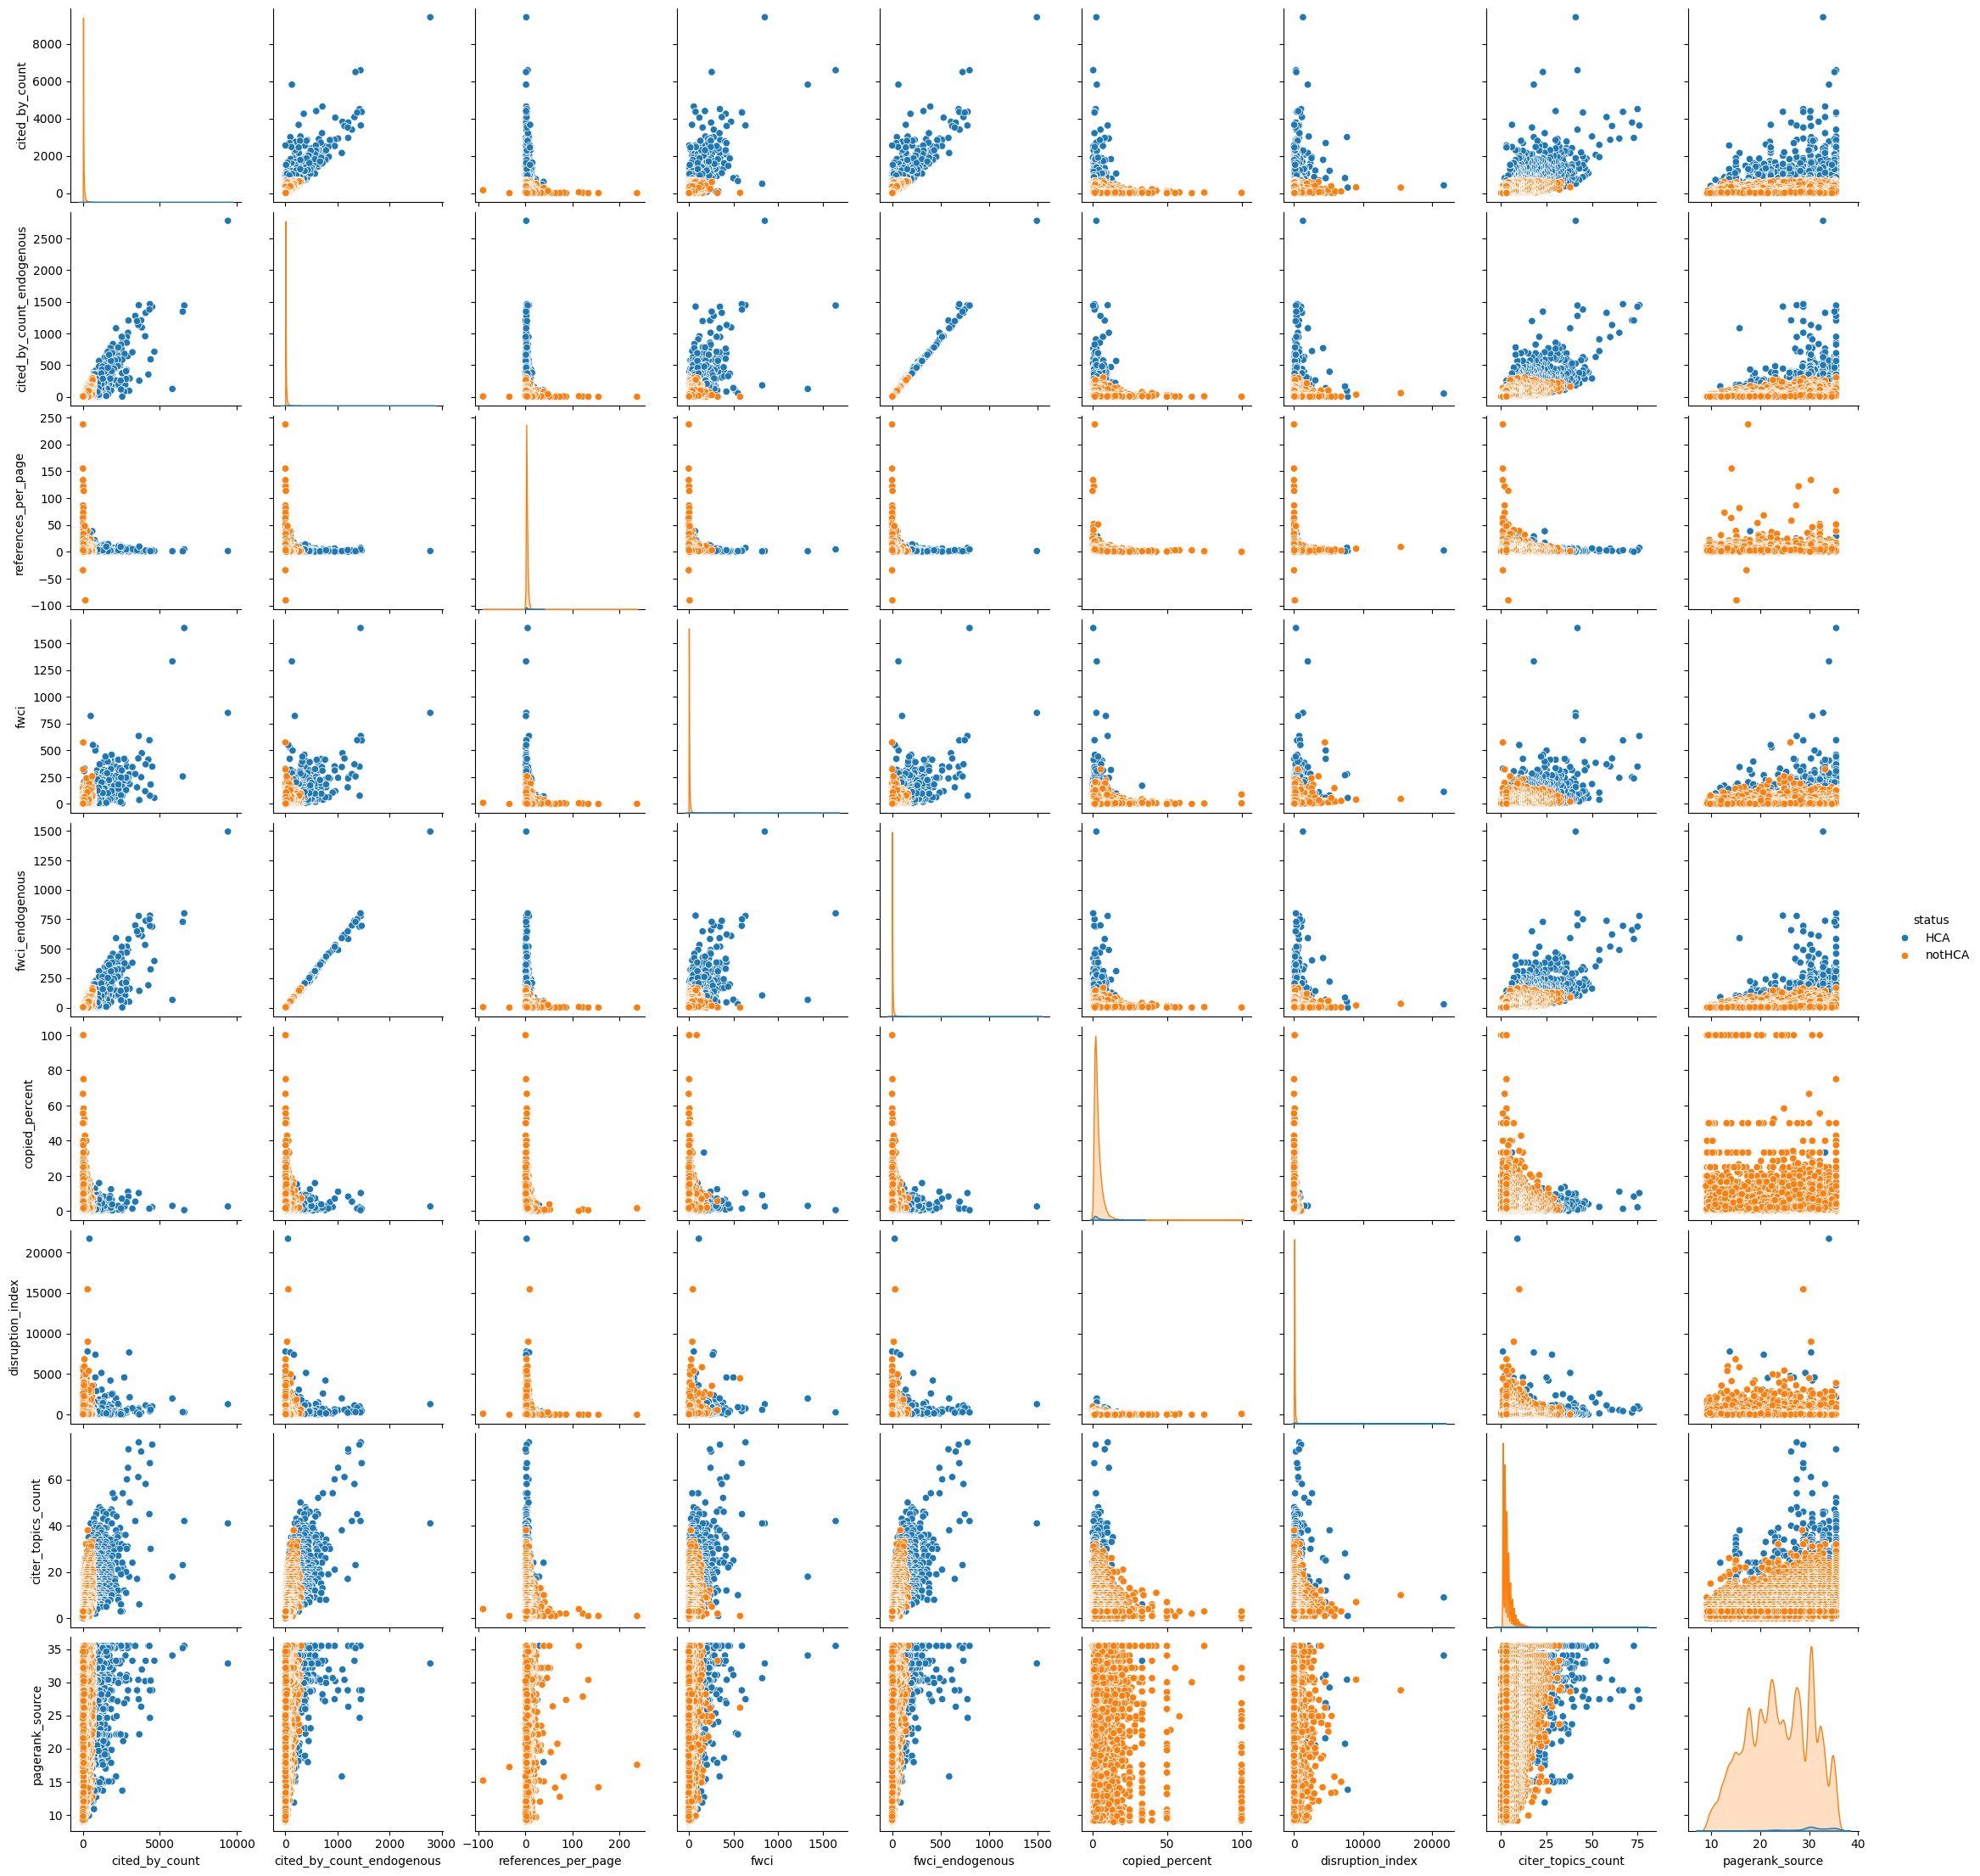

DONE!


In [160]:
if __name__ == "__main__":
    main()
    print("DONE!")